In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Cấu hình đường dẫn (Path dựa trên cấu trúc folder bạn gửi)
# Lưu ý: Trong Drive thực tế thường bắt đầu là '/content/drive/MyDrive/...'
file_path = '/content/drive/MyDrive/Colab Notebooks/datastorm_round_2_green_logistics/data/01_raw/fmcg_sales.csv'

# 3. Load Data
try:
    print("⏳ Đang đọc dữ liệu (1.1M dòng)...")
    df = pd.read_csv(file_path)
    print("✅ Load dữ liệu thành công!")
    print(f"Shape: {df.shape} (Dòng, Cột)")

    # Ép kiểu ngày tháng luôn để phân tích sau này
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    print("\n--- 3 Dòng mẫu dữ liệu ---")
    display(df.head(3))

    print("\n--- Danh sách các cột và kiểu dữ liệu ---")
    print(df.dtypes)

except FileNotFoundError:
    print(f"❌ Không tìm thấy file tại: {file_path}")
    print("Vui lòng kiểm tra lại đường dẫn trong Drive của bạn.")

Mounted at /content/drive
⏳ Đang đọc dữ liệu (1.1M dòng)...
✅ Load dữ liệu thành công!
Shape: (1100000, 33) (Dòng, Cột)

--- 3 Dòng mẫu dữ liệu ---


,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168



--- Danh sách các cột và kiểu dữ liệu ---
date              datetime64[ns]
year                       int64
month                      int64
day                        int64
weekofyear                 int64
weekday                    int64
is_weekend                 int64
is_holiday                 int64
temperature              float64
rain_mm                  float64
store_id                  object
country                   object
city                      object
channel                   object
latitude                 float64
longitude                float64
sku_id                    object
sku_name                  object
category                  object
subcategory               object
brand                     object
units_sold                 int64
list_price               float64
discount_pct             float64
promo_flag                 int64
gross_sales              float64
net_sales                float64
stock_on_hand              int64
stock_out_flag             int64


In [2]:
if 'df' in locals():
    print("========== DANH SÁCH CÁC KÊNH PHÂN PHỐI (CHANNEL) ==========")

    # 1. Lấy danh sách unique dưới dạng mảng
    unique_channels = df['channel'].unique()
    print(f"🔹 Các kênh phân phối hiện có: {list(unique_channels)}")

    print("\n--- Chi tiết số lượng giao dịch theo từng Channel ---")
    # 2. Đếm số lần xuất hiện và tỷ trọng phần trăm
    channel_counts = df['channel'].value_counts()
    channel_percent = df['channel'].value_counts(normalize=True) * 100

    # Kết hợp thành một DataFrame để xem cho đẹp
    channel_summary = pd.DataFrame({
        'Số dòng dữ liệu': channel_counts,
        'Tỷ trọng (%)': channel_percent.round(2)
    })

    display(channel_summary)

========== DANH SÁCH CÁC KÊNH PHÂN PHỐI (CHANNEL) ==========
🔹 Các kênh phân phối hiện có: ['Hypermarket', 'Supermarket', 'E-commerce', 'Convenience']

--- Chi tiết số lượng giao dịch theo từng Channel ---


,Số dòng dữ liệu,Tỷ trọng (%)
channel,,
Hypermarket,525600,47.78
Supermarket,262800,23.89
E-commerce,262800,23.89
Convenience,48800,4.44


In [3]:
if 'df' in locals():
    print("\n========== PHÂN TÍCH SẢN PHẨM (PRODUCT) ==========")

    # Số lượng SKU và Brand
    n_skus = df['sku_id'].nunique()
    n_brands = df['brand'].nunique()
    print(f"Tổng số SKU: {n_skus} | Tổng số Brand: {n_brands}")

    # Cấu trúc ngành hàng (Category -> Subcategory)
    print("\n--- Phân bố số lượng bản ghi theo Category ---")
    print(df['category'].value_counts())

    print("\n--- Chi tiết Subcategory (Top 10) ---")
    print(df['subcategory'].value_counts().head(10))

    # Kiểm tra giá bán (List Price) để xem phân khúc giá
    print("\n--- Thống kê giá niêm yết (List Price) ---")
    print(df['list_price'].describe().round(2))


========== PHÂN TÍCH SẢN PHẨM (PRODUCT) ==========
Tổng số SKU: 102 | Tổng số Brand: 6

--- Phân bố số lượng bản ghi theo Category ---
category
Beverages        266085
Snacks           261705
Personal Care    199290
Dairy            196005
Home Care        176915
Name: count, dtype: int64

--- Chi tiết Subcategory (Top 10) ---
subcategory
Soda          71175
Shampoo       70080
Toothpaste    70080
Cheese        68985
Milk          67890
Biscuits      67890
Chips         66795
Water         66795
Juice         65700
Chocolate     64605
Name: count, dtype: int64

--- Thống kê giá niêm yết (List Price) ---
count    1100000.00
mean           7.71
std            4.25
min            1.08
25%            4.20
50%            7.38
75%           11.65
max           14.80
Name: list_price, dtype: float64


In [4]:
import folium
import pandas as pd

if 'df' in locals():
    print("========== VẼ BẢN ĐỒ VỊ TRÍ 13 CỬA HÀNG (STORE MAP) ==========")

    # 1. Chuẩn bị dữ liệu: Gom nhóm theo Store để lấy tọa độ và thông tin tóm tắt
    # Dùng 'mean' cho lat/lon để đảm bảo lấy toạ độ số, 'first' cho text, 'sum' cho sản lượng
    store_map_data = df.groupby('store_id').agg({
        'latitude': 'mean',
        'longitude': 'mean',
        'city': 'first',
        'country': 'first',
        'channel': 'first',
        'units_sold': 'sum'  # Lấy tổng volume để hiển thị trong popup
    }).reset_index()

    print(f"📍 Tìm thấy {len(store_map_data)} địa điểm cửa hàng.")

    # 2. Tạo bản đồ nền
    # Lấy trung tâm bản đồ dựa trên trung bình toạ độ các điểm
    center_lat = store_map_data['latitude'].mean()
    center_lon = store_map_data['longitude'].mean()

    # Tạo map (zoom_start=6 để nhìn bao quát khu vực)
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB positron')

    # 3. Thiết lập màu sắc cho từng Channel (để phân biệt trên map)
    unique_channels = store_map_data['channel'].unique()
    # Danh sách màu có sẵn trong Folium
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'darkblue', 'cadetblue']
    channel_colors = {ch: colors[i % len(colors)] for i, ch in enumerate(unique_channels)}

    print("\n--- Chú thích màu sắc (Legend) ---")
    for ch, color in channel_colors.items():
        print(f"🔹 {ch}: {color.upper()}")

    # 4. Vẽ Marker cho từng cửa hàng
    for _, row in store_map_data.iterrows():
        # Nội dung hiển thị khi click vào điểm
        popup_info = f"""
        <b>ID:</b> {row['store_id']}<br>
        <b>City:</b> {row['city']}, {row['country']}<br>
        <b>Channel:</b> {row['channel']}<br>
        <b>Total Sold:</b> {row['units_sold']:,.0f} units
        """

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(popup_info, max_width=300),
            tooltip=f"{row['store_id']} ({row['channel']})", # Hiển thị khi di chuột vào
            icon=folium.Icon(color=channel_colors.get(row['channel'], 'gray'), icon='shopping-cart', prefix='fa')
        ).add_to(m)

    # 5. Hiển thị bản đồ
    display(m)
else:
    print("❌ Biến 'df' chưa tồn tại. Vui lòng chạy cell load dữ liệu trước.")

========== VẼ BẢN ĐỒ VỊ TRÍ 13 CỬA HÀNG (STORE MAP) ==========
📍 Tìm thấy 13 địa điểm cửa hàng.

--- Chú thích màu sắc (Legend) ---
🔹 Hypermarket: BLUE
🔹 Supermarket: GREEN
🔹 E-commerce: RED
🔹 Convenience: PURPLE


In [5]:
if 'df' in locals():
    print("\n========== PHÂN TÍCH LOGISTICS & KÊNH BÁN ==========")

    # 1. Địa lý
    n_countries = df['country'].nunique()
    n_cities = df['city'].nunique()
    n_stores = df['store_id'].nunique()
    print(f"Phạm vi: {n_countries} Quốc gia | {n_cities} Thành phố | {n_stores} Cửa hàng")

    print("\n--- Top 5 Quốc gia có lượng đơn hàng lớn nhất ---")
    print(df['country'].value_counts().head(5))

    # 2. Kênh phân phối (Channel) - Rất quan trọng cho việc chọn xe EV
    print("\n--- Tỷ trọng các Kênh bán hàng (Channel) ---")
    channel_stats = df['channel'].value_counts(normalize=True) * 100
    print(channel_stats)

    # 3. Kiểm tra dữ liệu kho bãi/vận chuyển
    print("\n--- Thống kê Lead Time (Thời gian giao hàng/nhập hàng) ---")
    if 'lead_time_days' in df.columns:
        print(df['lead_time_days'].describe().round(1))
    else:
        print("Không tìm thấy cột lead_time_days")


========== PHÂN TÍCH LOGISTICS & KÊNH BÁN ==========
Phạm vi: 7 Quốc gia | 9 Thành phố | 13 Cửa hàng

--- Top 5 Quốc gia có lượng đơn hàng lớn nhất ---
country
Italy      350400
Spain      262800
Germany    175200
Poland      87600
France      87600
Name: count, dtype: int64

--- Tỷ trọng các Kênh bán hàng (Channel) ---
channel
Hypermarket    47.781818
Supermarket    23.890909
E-commerce     23.890909
Convenience     4.436364
Name: proportion, dtype: float64

--- Thống kê Lead Time (Thời gian giao hàng/nhập hàng) ---
count    1100000.0
mean           6.5
std            2.0
min            1.0
25%            5.0
50%            6.0
75%            8.0
max           17.0
Name: lead_time_days, dtype: float64


In [6]:
if 'df' in locals():
    print("\n========== PHÂN TÍCH QUY MÔ & THỜI GIAN ==========")

    # 1. Khung thời gian
    print(f"Dữ liệu từ: {df['date'].min()} đến {df['date'].max()}")
    days_span = (df['date'].max() - df['date'].min()).days
    print(f"Tổng số ngày: {days_span} ngày")

    # 2. Tổng sản lượng (Volume) - Proxy cho tải trọng vận chuyển
    total_units = df['units_sold'].sum()
    print(f"Tổng số đơn vị sản phẩm đã bán (Units Sold): {total_units:,.0f}")

    # 3. Biến động theo tháng (Seasonality sơ bộ)
    # Gom nhóm theo tháng để xem tháng nào cao điểm
    df['YearMonth'] = df['date'].dt.to_period('M')
    monthly_vol = df.groupby('YearMonth')['units_sold'].sum()

    print("\n--- 5 Tháng có sản lượng bán cao nhất (Cao điểm Logistics) ---")
    print(monthly_vol.sort_values(ascending=False).head(5))


========== PHÂN TÍCH QUY MÔ & THỜI GIAN ==========
Dữ liệu từ: 2021-01-01 00:00:00 đến 2023-12-31 00:00:00
Tổng số ngày: 1094 ngày
Tổng số đơn vị sản phẩm đã bán (Units Sold): 65,115,982

--- 5 Tháng có sản lượng bán cao nhất (Cao điểm Logistics) ---
YearMonth
2021-08    2002722
2023-07    1989263
2022-07    1989175
2021-07    1978893
2023-08    1965591
Freq: M, Name: units_sold, dtype: int64


---
mơi

In [7]:
if 'df' in locals():
    print("========== HỒ SƠ NĂNG LỰC 13 STORE (PROFILING) ==========")

    # Gom nhóm theo Store để xem quy mô
    store_profile = df.groupby('store_id').agg({
        'units_sold': 'sum',                        # Tổng sản lượng
        'gross_sales': 'sum',                       # Tổng doanh thu
        'sku_id': 'nunique',                        # Độ đa dạng hàng hóa
        'channel': lambda x: x.mode()[0],           # Kênh bán hàng chủ đạo
        'city': lambda x: x.mode()[0],              # Thành phố gốc (trong data cũ)
        'date': 'count'                             # Số dòng dữ liệu (tần suất)
    }).sort_values(by='units_sold', ascending=False).reset_index()

    # Tính tỷ trọng % đóng góp của từng store vào tổng volume
    total_vol = store_profile['units_sold'].sum()
    store_profile['vol_share_%'] = (store_profile['units_sold'] / total_vol * 100).round(2)

    print("\n--- Bảng xếp hạng quy mô 13 Store ---")
    display(store_profile)

    # Kiểm tra sự chênh lệch: Store lớn nhất gấp mấy lần Store nhỏ nhất?
    max_vol = store_profile['units_sold'].max()
    min_vol = store_profile['units_sold'].min()
    print(f"\nStore lớn nhất gấp {max_vol/min_vol:.1f} lần Store nhỏ nhất.")

========== HỒ SƠ NĂNG LỰC 13 STORE (PROFILING) ==========

--- Bảng xếp hạng quy mô 13 Store ---


,store_id,units_sold,gross_sales,sku_id,channel,city,date,vol_share_%
0,STORE0004,6057129,47758567.91,80,Hypermarket,Berlin,87600,9.30
1,STORE0006,6014974,43631135.12,80,Hypermarket,Paris,87600,9.24
2,STORE0011,5985522,43180070.02,80,Hypermarket,Rome,87600,9.19
3,STORE0005,5860180,43535481.19,80,Hypermarket,Warsaw,87600,9.00
4,STORE0008,5742174,44018767.93,80,Hypermarket,Vienna,87600,8.82
5,STORE0001,5681442,43008034.15,80,Hypermarket,Berlin,87600,8.73
6,STORE0009,5297695,38726446.42,80,E-commerce,Barcelona,87600,8.14
7,STORE0012,5243338,39822212.80,80,E-commerce,Madrid,87600,8.05
8,STORE0010,5106947,36969431.30,80,E-commerce,Milan,87600,7.84
9,STORE0002,4249838,31056775.20,80,Supermarket,Rome,87600,6.53



Store lớn nhất gấp 3.5 lần Store nhỏ nhất.


In [8]:
if 'df' in locals():
    # Assuming an average weight per unit of 0.5 kg (0.0005 tons) for FMCG products
    # This is a placeholder and can be refined if more specific product weight data is available.
    df['total_weight_ton'] = df['units_sold'] * 0.0005

    if 'total_weight_ton' in df.columns:
        print("========== PHÂN TÍCH TẢI TRỌNG NGÀY (DAILY LOAD) ==========")

        # Tính tổng tấn hàng mỗi ngày cho từng store
        daily_load = df.groupby(['date', 'store_id'])['total_weight_ton'].sum().reset_index()

        # Thống kê trung bình và max tải trọng ngày của từng Store
        load_stats = daily_load.groupby('store_id')['total_weight_ton'].agg(['mean', 'max', 'min']).sort_values(by='mean', ascending=False)

        print("\n--- Tải trọng trung bình (Tấn/Ngày) cần vận chuyển đến từng Store ---")
        display(load_stats.round(2))

        print("\n--- Đánh giá sơ bộ cho quy mô TP.HCM ---")
        avg_load_all = load_stats['mean'].mean()
        print(f"Trung bình toàn mạng lưới: {avg_load_all:.2f} tấn/ngày/store")
        if avg_load_all > 20:
            print("⚠️ CẢNH BÁO: Volume quá lớn so với cửa hàng bán lẻ thông thường ở HCM.")
            print("-> Cần hệ số Scale Down (ví dụ: chia cho 10 hoặc 20).")
        else:
            print("✅ Volume ở mức chấp nhận được.")

========== PHÂN TÍCH TẢI TRỌNG NGÀY (DAILY LOAD) ==========

--- Tải trọng trung bình (Tấn/Ngày) cần vận chuyển đến từng Store ---


,mean,max,min
store_id,,,
STORE0004,2.77,3.81,2.14
STORE0006,2.75,3.71,2.09
STORE0011,2.73,3.73,2.12
STORE0005,2.68,3.57,2.11
STORE0008,2.62,3.72,2.06
STORE0001,2.59,3.47,2.01
STORE0009,2.42,3.25,1.90
STORE0012,2.39,3.35,1.85
STORE0010,2.33,3.19,1.77



--- Đánh giá sơ bộ cho quy mô TP.HCM ---
Trung bình toàn mạng lưới: 2.29 tấn/ngày/store
✅ Volume ở mức chấp nhận được.


In [9]:
if 'df' in locals():
    print("========== CƠ CẤU NGÀNH HÀNG TỪNG STORE ==========")

    # Tạo bảng pivot: Dòng là Store, Cột là Category, Giá trị là % Unit Sold
    cat_mix = pd.crosstab(df['store_id'], df['category'], values=df['units_sold'], aggfunc='sum', normalize='index') * 100

    print("\n--- Tỷ lệ % ngành hàng tại mỗi Store ---")
    display(cat_mix.round(1))

    # Kiểm tra xem có Store nào 'kén cá chọn canh' không (chỉ bán 1-2 loại)
    # Hay tất cả đều bán tạp hóa (General Trade)

========== CƠ CẤU NGÀNH HÀNG TỪNG STORE ==========

--- Tỷ lệ % ngành hàng tại mỗi Store ---


category,Beverages,Dairy,Home Care,Personal Care,Snacks
store_id,,,,,
STORE0001,27.0,15.9,16.1,15.7,25.3
STORE0002,30.5,14.2,14.2,15.1,25.9
STORE0003,29.6,18.7,11.3,16.3,24.2
STORE0004,24.5,19.0,10.7,18.0,27.8
STORE0005,29.9,16.4,18.2,13.4,22.2
STORE0006,28.7,14.6,10.6,17.8,28.2
STORE0007,25.4,12.2,15.0,18.3,29.2
STORE0008,27.3,13.2,13.4,21.3,24.8
STORE0009,27.7,16.3,16.2,16.1,23.7


In [10]:
if 'df' in locals():
    print("========== THỐNG KÊ CHI TIẾT CỘT CHANNEL ==========")

    # 1. Đếm số lần xuất hiện (Số dòng dữ liệu)
    counts = df['channel'].value_counts()
    print("\n--- Số lượng giao dịch theo Channel ---")
    print(counts)

    # 2. Tính tỷ trọng phần trăm
    percents = df['channel'].value_counts(normalize=True) * 100
    print("\n--- Tỷ trọng (%) ---")
    print(percents.round(2))

    # 3. Kiểm tra xem mỗi Channel gắn với bao nhiêu Store ID
    # Để biết kênh Hypermarket đang bao gồm mấy ông Store
    print("\n--- Phân bố Store ID theo Channel ---")
    channel_store_map = df.groupby('channel')['store_id'].nunique()
    print(channel_store_map)

    # Liệt kê cụ thể Store ID nào thuộc Channel nào (để sau này dễ bốc thuốc)
    print("\n--- Danh sách Store ID cụ thể cho từng Channel ---")
    for channel in df['channel'].unique():
        stores = df[df['channel'] == channel]['store_id'].unique()
        print(f"🔹 {channel}: {list(stores)}")

========== THỐNG KÊ CHI TIẾT CỘT CHANNEL ==========

--- Số lượng giao dịch theo Channel ---
channel
Hypermarket    525600
Supermarket    262800
E-commerce     262800
Convenience     48800
Name: count, dtype: int64

--- Tỷ trọng (%) ---
channel
Hypermarket    47.78
Supermarket    23.89
E-commerce     23.89
Convenience     4.44
Name: proportion, dtype: float64

--- Phân bố Store ID theo Channel ---
channel
Convenience    1
E-commerce     3
Hypermarket    6
Supermarket    3
Name: store_id, dtype: int64

--- Danh sách Store ID cụ thể cho từng Channel ---
🔹 Hypermarket: ['STORE0001', 'STORE0004', 'STORE0005', 'STORE0006', 'STORE0008', 'STORE0011']
🔹 Supermarket: ['STORE0002', 'STORE0003', 'STORE0007']
🔹 E-commerce: ['STORE0009', 'STORE0010', 'STORE0012']
🔹 Convenience: ['STORE0013']


In [11]:
if 'df' in locals():
    print("========== THỐNG KÊ DANH MỤC SẢN PHẨM ==========")

    # 1. Đếm số lượng unique
    n_categories = df['category'].nunique()
    n_subcategories = df['subcategory'].nunique()

    print(f"🔹 Tổng số Ngành hàng (Category): {n_categories}")
    print(f"🔹 Tổng số Ngành hàng phụ (Subcategory): {n_subcategories}")

    # 2. Hiển thị danh sách cụ thể các Category
    print("\n--- Danh sách các Category cụ thể ---")
    print(df['category'].unique())

    # 3. Hiển thị số lượng Subcategory tương ứng trong mỗi Category
    # Cách này giúp bạn thấy cấu trúc phân cấp (Hierarchy)
    cat_structure = df.groupby('category')['subcategory'].nunique().sort_values(ascending=False)

    print("\n--- Số lượng Subcategory trong mỗi Category ---")
    print(cat_structure)

========== THỐNG KÊ DANH MỤC SẢN PHẨM ==========
🔹 Tổng số Ngành hàng (Category): 5
🔹 Tổng số Ngành hàng phụ (Subcategory): 17

--- Danh sách các Category cụ thể ---
['Personal Care' 'Beverages' 'Dairy' 'Snacks' 'Home Care']

--- Số lượng Subcategory trong mỗi Category ---
category
Beverages        4
Snacks           4
Dairy            3
Home Care        3
Personal Care    3
Name: subcategory, dtype: int64


In [12]:
if 'df' in locals():
    print("========== DANH SÁCH CHI TIẾT CẤU TRÚC NGÀNH HÀNG ==========\n")

    # Gom nhóm theo category và lấy danh sách subcategory duy nhất
    category_map = df.groupby('category')['subcategory'].unique()

    for cat, subcats in category_map.items():
        print(f"📂 Category: {cat}")
        # In các subcategory với định dạng gạch đầu dòng
        for sub in sorted(subcats):
            print(f"   └── {sub}")
        print("-" * 30)

========== DANH SÁCH CHI TIẾT CẤU TRÚC NGÀNH HÀNG ==========

📂 Category: Beverages
   └── Energy drink
   └── Juice
   └── Soda
   └── Water
------------------------------
📂 Category: Dairy
   └── Cheese
   └── Milk
   └── Yogurt
------------------------------
📂 Category: Home Care
   └── Cleaner
   └── Detergent
   └── Softener
------------------------------
📂 Category: Personal Care
   └── Shampoo
   └── Soap
   └── Toothpaste
------------------------------
📂 Category: Snacks
   └── Biscuits
   └── Chips
   └── Chocolate
   └── Nuts
------------------------------


advanced eda

In [13]:
if 'df' in locals():
    print("========== PHÂN TÍCH TẦN SUẤT ĐẶT HÀNG ==========")

    # Đếm số ngày có phát sinh đơn hàng của từng Store trong 3 năm
    total_days = df['date'].nunique()
    store_freq = df.groupby('store_id')['date'].nunique().reset_index()
    store_freq.columns = ['store_id', 'active_days']
    store_freq['frequency_pct'] = (store_freq['active_days'] / total_days * 100).round(1)

    print(f"Tổng số ngày trong dữ liệu: {total_days} ngày")
    print("\n--- Tần suất hoạt động của từng Store ---")
    display(store_freq.sort_values('active_days'))

    # Kiểm tra xem có Store nào 'nghỉ bán' vào cuối tuần không?
    weekend_sales = df.groupby(['store_id', 'is_weekend'])['units_sold'].sum().unstack()
    print("\n--- Kiểm tra bán hàng cuối tuần (0: Trong tuần, 1: Cuối tuần) ---")
    display(weekend_sales.head())

========== PHÂN TÍCH TẦN SUẤT ĐẶT HÀNG ==========
Tổng số ngày trong dữ liệu: 1095 ngày

--- Tần suất hoạt động của từng Store ---


,store_id,active_days,frequency_pct
0,STORE0001,1095,100.0
1,STORE0002,1095,100.0
2,STORE0003,1095,100.0
3,STORE0004,1095,100.0
4,STORE0005,1095,100.0
5,STORE0006,1095,100.0
6,STORE0007,1095,100.0
7,STORE0008,1095,100.0
8,STORE0009,1095,100.0
9,STORE0010,1095,100.0



--- Kiểm tra bán hàng cuối tuần (0: Trong tuần, 1: Cuối tuần) ---


is_weekend,0,1
store_id,,
STORE0001,3838344,1843098
STORE0002,2867426,1382412
STORE0003,2712449,1307018
STORE0004,4085374,1971755
STORE0005,3954244,1905936


========== BIỂU ĐỒ PHÂN PHỐI TẢI TRỌNG NGÀY ==========


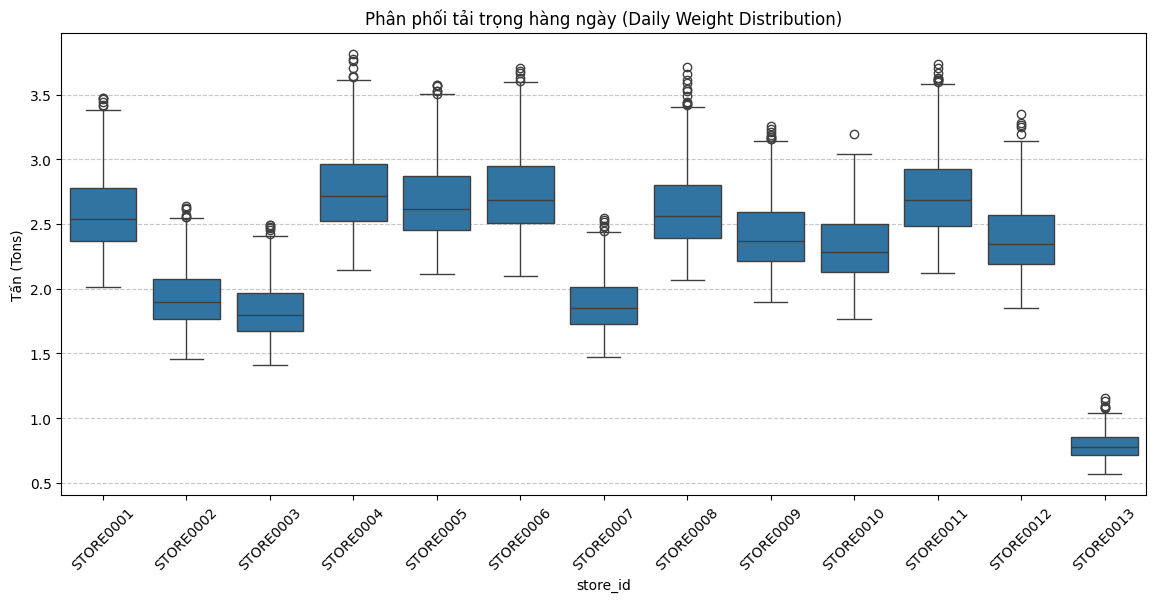


--- Số ngày Store nhập hàng dưới 1 Tấn (Cơ hội ghép chuyến) ---
store_id
STORE0013    1065
Name: date, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'total_weight_ton' in df.columns:
    print("========== BIỂU ĐỒ PHÂN PHỐI TẢI TRỌNG NGÀY ==========")

    # Tính tải trọng theo ngày cho từng store
    daily_store_load = df.groupby(['date', 'store_id'])['total_weight_ton'].sum().reset_index()

    # Vẽ boxplot để xem biên độ dao động
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=daily_store_load, x='store_id', y='total_weight_ton')
    plt.title('Phân phối tải trọng hàng ngày (Daily Weight Distribution)')
    plt.ylabel('Tấn (Tons)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Thống kê số ngày mà Store lớn nhập hàng ÍT (ví dụ < 1 tấn)
    low_vol_days = daily_store_load[daily_store_load['total_weight_ton'] < 1.0].groupby('store_id')['date'].count()
    print("\n--- Số ngày Store nhập hàng dưới 1 Tấn (Cơ hội ghép chuyến) ---")
    print(low_vol_days)

In [15]:
if 'df' in locals():
    print("========== ĐỘ PHỦ SKU TẠI CÁC STORE ==========")

    # Đếm số lượng SKU unique mà mỗi store từng bán
    sku_breadth = df.groupby('store_id')['sku_id'].nunique().sort_values(ascending=False)

    print("\n--- Số lượng SKU kinh doanh tại từng Store (Max 102) ---")
    print(sku_breadth)

    # Xem thử STORE0013 (Convenience) bán những nhóm hàng nào là chính?
    conv_store = df[df['store_id'] == 'STORE0013']
    conv_mix = conv_store.groupby('subcategory')['units_sold'].sum().sort_values(ascending=False).head(5)

    print("\n--- Top 5 nhóm hàng bán chạy nhất tại STORE0013 (Convenience) ---")
    print(conv_mix)

========== ĐỘ PHỦ SKU TẠI CÁC STORE ==========

--- Số lượng SKU kinh doanh tại từng Store (Max 102) ---
store_id
STORE0001    80
STORE0002    80
STORE0003    80
STORE0004    80
STORE0005    80
STORE0006    80
STORE0007    80
STORE0008    80
STORE0009    80
STORE0010    80
STORE0011    80
STORE0012    80
STORE0013    45
Name: sku_id, dtype: int64

--- Top 5 nhóm hàng bán chạy nhất tại STORE0013 (Convenience) ---
subcategory
Soda          220502
Chips         199057
Water         193838
Toothpaste    174688
Chocolate     152712
Name: units_sold, dtype: int64


========== PHÂN TÍCH TÁC ĐỘNG CỦA LỊCH (RAW DATA) ==========

--- Trung bình Units Sold: Cuối tuần vs Trong tuần ---


,is_weekend,units_sold,Label
0,0,56.020186,Trong tuần (Weekday)
1,1,67.096283,Cuối tuần (Weekend)


/tmp/ipython-input-1341916549.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekend_impact, x='Label', y='units_sold', palette='pastel')


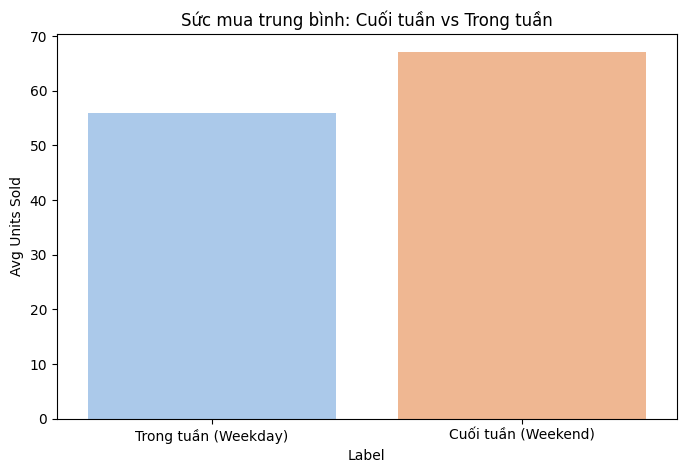


--- Trung bình Units Sold: Ngày Lễ vs Ngày Thường ---


,is_holiday,units_sold,Label
0,0,59.147099,Ngày thường
1,1,62.742368,Ngày Lễ (Holiday)


/tmp/ipython-input-1341916549.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holiday_impact, x='Label', y='units_sold', palette='Set2')


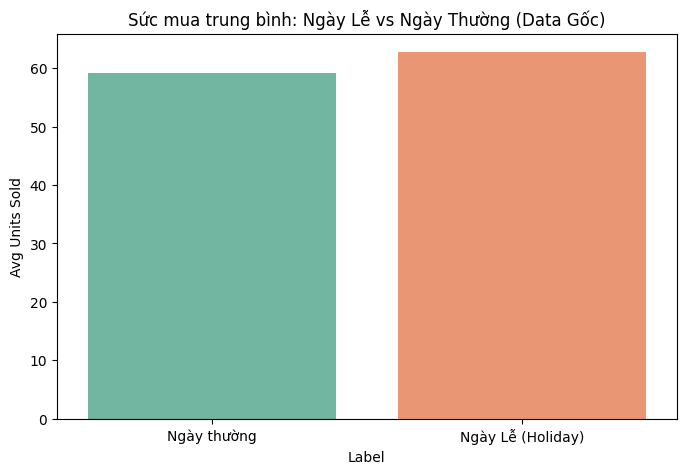

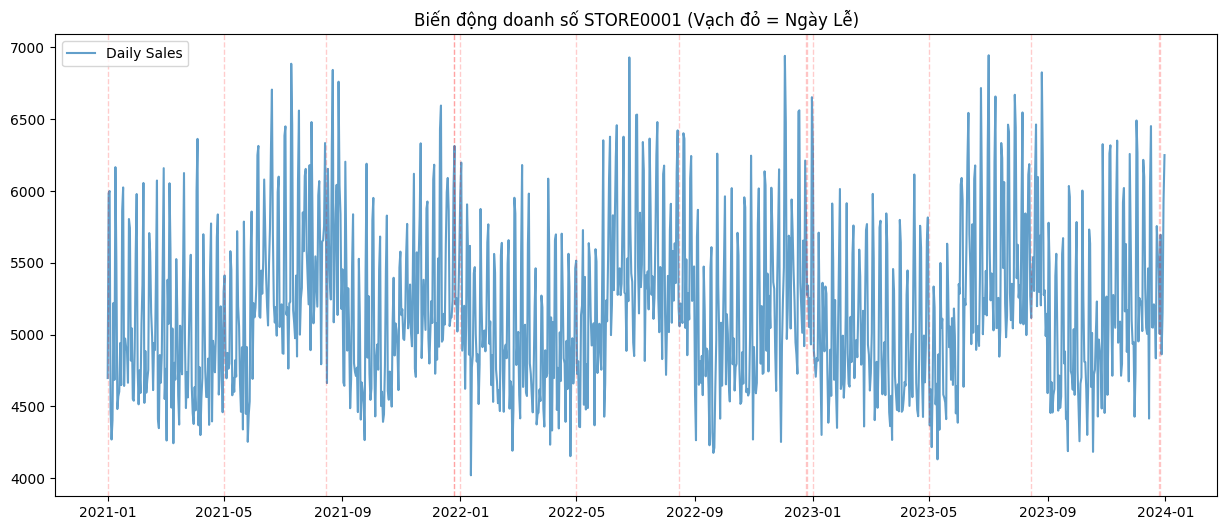

In [16]:
# --- CELL 1: EDA HOLIDAY & WEEKEND (RAW DATA) ---
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    print("========== PHÂN TÍCH TÁC ĐỘNG CỦA LỊCH (RAW DATA) ==========")

    # 1. Tác động của Cuối tuần (Weekend)
    # Gom nhóm và tính trung bình doanh số
    weekend_impact = df.groupby('is_weekend')['units_sold'].mean().reset_index()
    weekend_impact['Label'] = weekend_impact['is_weekend'].map({0: 'Trong tuần (Weekday)', 1: 'Cuối tuần (Weekend)'})

    print("\n--- Trung bình Units Sold: Cuối tuần vs Trong tuần ---")
    display(weekend_impact)

    # Vẽ biểu đồ
    plt.figure(figsize=(8, 5))
    sns.barplot(data=weekend_impact, x='Label', y='units_sold', palette='pastel')
    plt.title('Sức mua trung bình: Cuối tuần vs Trong tuần')
    plt.ylabel('Avg Units Sold')
    plt.show()

    # 2. Tác động của Ngày lễ (Holiday) - Dữ liệu gốc Châu Âu
    # Lưu ý: Cột is_holiday trong data gốc là lễ của Châu Âu
    holiday_impact = df.groupby('is_holiday')['units_sold'].mean().reset_index()
    holiday_impact['Label'] = holiday_impact['is_holiday'].map({0: 'Ngày thường', 1: 'Ngày Lễ (Holiday)'})

    print("\n--- Trung bình Units Sold: Ngày Lễ vs Ngày Thường ---")
    display(holiday_impact)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=holiday_impact, x='Label', y='units_sold', palette='Set2')
    plt.title('Sức mua trung bình: Ngày Lễ vs Ngày Thường (Data Gốc)')
    plt.ylabel('Avg Units Sold')
    plt.show()

    # 3. Kiểm tra chi tiết 1 Store (Ví dụ STORE0001)
    # Xem biểu đồ theo thời gian để thấy đỉnh (peak) có trùng với lễ không
    sample_store = df[df['store_id'] == 'STORE0001'].groupby('date')['units_sold'].sum().reset_index()

    plt.figure(figsize=(15, 6))
    plt.plot(sample_store['date'], sample_store['units_sold'], label='Daily Sales', alpha=0.7)

    # Đánh dấu các ngày lễ trên biểu đồ
    # Lấy danh sách ngày lễ từ data gốc
    holidays = df[df['is_holiday'] == 1]['date'].unique()
    # Chỉ lấy holiday nằm trong khoảng thời gian của sample_store
    holidays = [d for d in holidays if d >= sample_store['date'].min() and d <= sample_store['date'].max()]

    # Vẽ các đường dọc màu đỏ cho ngày lễ
    for day in holidays:
        plt.axvline(x=day, color='red', alpha=0.2, linestyle='--', linewidth=1)

    plt.title('Biến động doanh số STORE0001 (Vạch đỏ = Ngày Lễ)')
    plt.legend()
    plt.show()

In [17]:
if 'df' in locals():
    print("========== DANH SÁCH CHI TIẾT CÁC NGÀY LỄ (IS_HOLIDAY = 1) ==========")

    # 1. Lọc lấy các ngày unique có is_holiday = 1
    holiday_dates = df[df['is_holiday'] == 1]['date'].unique()

    # 2. Sắp xếp theo thời gian
    holiday_dates = sorted(holiday_dates)

    print(f"🔹 Tổng cộng có: {len(holiday_dates)} ngày lễ trong suốt giai đoạn dữ liệu.")

    # 3. Tạo DataFrame nhỏ để hiển thị cho đẹp (Ngày + Thứ)
    holiday_df_list = pd.DataFrame({'Date': holiday_dates})

    # Ép kiểu datetime nếu chưa phải (đề phòng)
    holiday_df_list['Date'] = pd.to_datetime(holiday_df_list['Date'])

    # Thêm cột Thứ (Monday, Tuesday...)
    holiday_df_list['Day_of_Week'] = holiday_df_list['Date'].dt.day_name()

    # Thêm cột Năm để dễ group
    holiday_df_list['Year'] = holiday_df_list['Date'].dt.year

    print("\n--- Bảng chi tiết ngày tháng ---")
    # Hiển thị tất cả các dòng (nếu list dài colab hay ẩn bớt, nhưng list holiday thường ngắn)
    with pd.option_context('display.max_rows', None):
        display(holiday_df_list)

    # 4. Thống kê số ngày lễ theo năm
    print("\n--- Thống kê số ngày lễ theo từng năm ---")
    print(holiday_df_list['Year'].value_counts().sort_index())

    # 5. Kiểm tra nhanh doanh số trung bình vào các ngày này so với ngày thường
    avg_holiday_sales = df[df['is_holiday'] == 1]['units_sold'].mean()
    avg_normal_sales = df[df['is_holiday'] == 0]['units_sold'].mean()

    print("\n--- So sánh sức mua trung bình (Units Sold) ---")
    print(f"🛒 Ngày Lễ: {avg_holiday_sales:.2f}")
    print(f"🛒 Ngày Thường: {avg_normal_sales:.2f}")
    print(f"👉 Chênh lệch: Ngày lễ bán {'CAO' if avg_holiday_sales > avg_normal_sales else 'THẤP'} hơn ngày thường {abs(avg_holiday_sales - avg_normal_sales)/avg_normal_sales*100:.1f}%")

========== DANH SÁCH CHI TIẾT CÁC NGÀY LỄ (IS_HOLIDAY = 1) ==========
🔹 Tổng cộng có: 15 ngày lễ trong suốt giai đoạn dữ liệu.

--- Bảng chi tiết ngày tháng ---


,Date,Day_of_Week,Year
0,2021-01-01,Friday,2021
1,2021-05-01,Saturday,2021
2,2021-08-15,Sunday,2021
3,2021-12-25,Saturday,2021
4,2021-12-26,Sunday,2021
5,2022-01-01,Saturday,2022
6,2022-05-01,Sunday,2022
7,2022-08-15,Monday,2022
8,2022-12-25,Sunday,2022
9,2022-12-26,Monday,2022



--- Thống kê số ngày lễ theo từng năm ---
Year
2021    5
2022    5
2023    5
Name: count, dtype: int64

--- So sánh sức mua trung bình (Units Sold) ---
🛒 Ngày Lễ: 62.74
🛒 Ngày Thường: 59.15
👉 Chênh lệch: Ngày lễ bán CAO hơn ngày thường 6.1%
